# **LASSO regression**

Marek Šugár

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Lasso

# In case of convergence problem, supress warning
import warnings

warnings.filterwarnings("ignore")

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **LASSO regression**

In [65]:
performance_trackerENPH = {}

for Alpha in [0.001, 0.1, 1]:
    for window_length in range(2, 31):
        for ticker in ["ENPH"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Lasso(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerENPH[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.001, 2) 15.578860911989652
(0.001, 3) 7.202711322350926
(0.001, 4) 5.9037525284920305
(0.001, 5) 5.632524828122488
(0.001, 6) 5.242611472289638
(0.001, 7) 5.160768633135785
(0.001, 8) 5.202704367622238
(0.001, 9) 5.251787873814876
(0.001, 10) 5.240383284009398
(0.001, 11) 5.238377848463326
(0.001, 12) 5.280038220273625
(0.001, 13) 5.283732515102623
(0.001, 14) 5.317568287969963
(0.001, 15) 5.429921372101395
(0.001, 16) 5.425818291826133
(0.001, 17) 5.378509513617559
(0.001, 18) 5.390118389032093
(0.001, 19) 5.45068899293069
(0.001, 20) 5.514628644124364
(0.001, 21) 5.598370394164726
(0.001, 22) 5.607602405151073
(0.001, 23) 5.646668036789529
(0.001, 24) 5.722354044817968
(0.001, 25) 5.700639168651402
(0.001, 26) 5.724634066818016
(0.001, 27) 5.793192585302748
(0.001, 28) 5.859319787030405
(0.001, 29) 5.891669576296998
(0.001, 30) 5.917697885710292
(0.1, 2) 13.290735232648121
(0.1, 3) 5.843953435398449
(0.1, 4) 4.9185758703788744
(0.1, 5) 4.805896172084143
(0.1, 6) 4.774314679132804


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

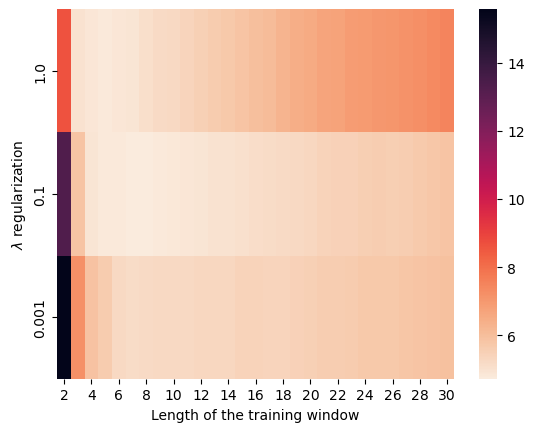

In [66]:
df = pd.Series(performance_trackerENPH).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [77]:
np.argmin(list(performance_trackerENPH.values()))

np.int64(35)

In [67]:
performance_trackerROP = {}

for Alpha in [0.001, 0.1, 1]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["ROP"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Lasso(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerROP[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.001, 2) 4.12387666597624
(0.001, 3) 2.3103382505578356
(0.001, 4) 1.799938381027885
(0.001, 5) 1.677117393532377
(0.001, 6) 1.6000035563808208
(0.001, 7) 1.5604150770150278
(0.001, 8) 1.5211654666865175
(0.001, 9) 1.487874102651696
(0.001, 10) 1.4958772424567275
(0.001, 11) 1.483581933464887
(0.001, 12) 1.4764196614152427
(0.001, 13) 1.4984264665490894
(0.001, 14) 1.5096207634551708
(0.001, 15) 1.5346159825753798
(0.001, 16) 1.54206415556088
(0.001, 17) 1.5532564923083547
(0.001, 18) 1.5646194263292628
(0.001, 19) 1.592588373546161
(0.001, 20) 1.5857484477133983
(0.001, 21) 1.5995686727263085
(0.001, 22) 1.592795564726363
(0.001, 23) 1.6021464972066908
(0.001, 24) 1.6233239032570825
(0.001, 25) 1.6139417071904167
(0.001, 26) 1.5992439423527367
(0.001, 27) 1.6038240206507834
(0.001, 28) 1.63128363326867
(0.001, 29) 1.6457259470754384
(0.001, 30) 1.6495574155778747
(0.1, 2) 3.9504022644169687
(0.1, 3) 1.951097664420487
(0.1, 4) 1.5445277953145802
(0.1, 5) 1.471342732360213
(0.1, 6) 1.

Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

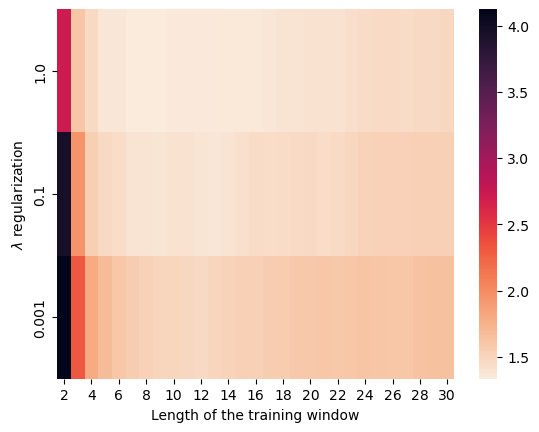

In [68]:
df = pd.Series(performance_trackerROP).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [76]:
np.argmin(list(performance_trackerROP.values()))

np.int64(65)

In [69]:
performance_trackerSMCI = {}

for Alpha in [0.001, 0.1, 1]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["SMCI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Lasso(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerSMCI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.001, 2) 11.258294298071636
(0.001, 3) 5.208348264165427
(0.001, 4) 4.546714169953439
(0.001, 5) 4.198792986242469
(0.001, 6) 4.189113879556775
(0.001, 7) 4.125242528313567
(0.001, 8) 4.162657182869406
(0.001, 9) 4.36826588155742
(0.001, 10) 4.268634227549936
(0.001, 11) 4.2902746943643555
(0.001, 12) 4.356794612670968
(0.001, 13) 4.510668427169012
(0.001, 14) 4.450197194480672
(0.001, 15) 4.349335660210655
(0.001, 16) 4.282409173190236
(0.001, 17) 4.40806070736836
(0.001, 18) 4.3932493789417455
(0.001, 19) 4.3884853851987655
(0.001, 20) 4.464722350483058
(0.001, 21) 4.529160927196863
(0.001, 22) 4.580955976439684
(0.001, 23) 4.619210676045325
(0.001, 24) 4.642227098963779
(0.001, 25) 4.715926294355189
(0.001, 26) 4.793523571185021
(0.001, 27) 4.90068560582569
(0.001, 28) 4.9537014045364325
(0.001, 29) 5.0279458166927835
(0.001, 30) 5.079413157628327
(0.1, 2) 7.0325532756487785
(0.1, 3) 4.144565076167153
(0.1, 4) 4.031328802966195
(0.1, 5) 4.188052185997458
(0.1, 6) 4.169538869065936

Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

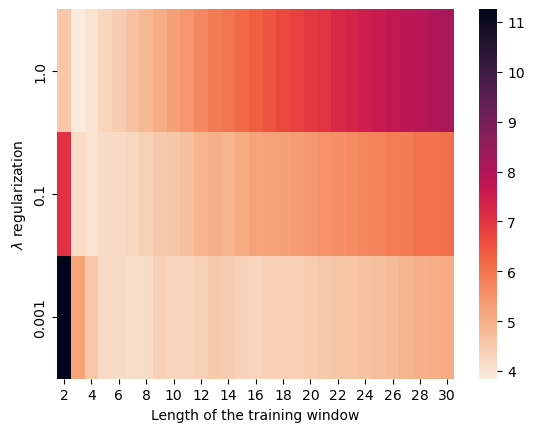

In [70]:
df = pd.Series(performance_trackerSMCI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [75]:
np.argmin(list(performance_trackerSMCI.values()))

np.int64(59)

In [71]:
performance_trackerMSI = {}

for Alpha in [0.001, 0.1, 1]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["MSI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Lasso(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerMSI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.001, 2) 4.881555783145096
(0.001, 3) 2.5242684610821557
(0.001, 4) 1.872164958128645
(0.001, 5) 1.7583593619539268
(0.001, 6) 1.6423260350611588
(0.001, 7) 1.5787840559314232
(0.001, 8) 1.5627022882277024
(0.001, 9) 1.5664012383706354
(0.001, 10) 1.5460847257322468
(0.001, 11) 1.542005050972991
(0.001, 12) 1.5267453333150893
(0.001, 13) 1.5180653513167788
(0.001, 14) 1.5272471846162252
(0.001, 15) 1.5535575631073681
(0.001, 16) 1.5615969624082675
(0.001, 17) 1.5831713694679714
(0.001, 18) 1.595872007919785
(0.001, 19) 1.608756431901001
(0.001, 20) 1.6393307139010178
(0.001, 21) 1.674872987939993
(0.001, 22) 1.7079071500399103
(0.001, 23) 1.7247746104487947
(0.001, 24) 1.7335054000149925
(0.001, 25) 1.7368796052296398
(0.001, 26) 1.761303122659658
(0.001, 27) 1.7722018472098073
(0.001, 28) 1.7853165896005372
(0.001, 29) 1.8211116274003978
(0.001, 30) 1.8431536742366523
(0.1, 2) 4.510984858630704
(0.1, 3) 2.1029004925208126
(0.1, 4) 1.6300143469982682
(0.1, 5) 1.5075358948959474
(0.1,

Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

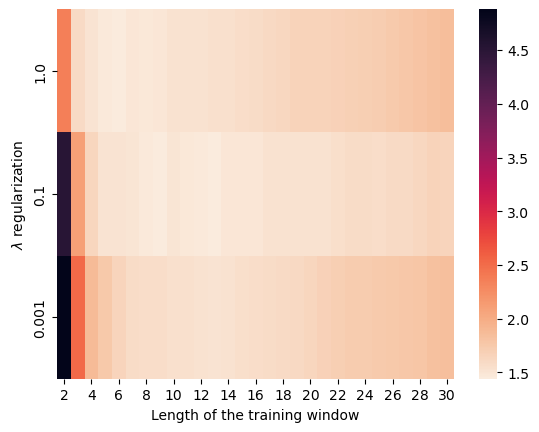

In [72]:
df = pd.Series(performance_trackerMSI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [17]:
performance_trackerENPH_focused = {}

for Alpha in np.arange(4.5, 4.7, 0.01):
    for ticker in ["ENPH"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
            
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 3
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue
            
            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features)
            Test_Features = scaler.transform(Test_Features)

            # Fit KNN
            MODEL = Lasso(alpha=Alpha)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
        # Save results
        performance_trackerENPH_focused[Alpha] = np.mean(MAPEs)
        print(Alpha, np.mean(MAPEs))


4.5 4.441131085116036
4.51 4.440777516948561
4.52 4.440384726494565
4.529999999999999 4.440260815095627
4.539999999999999 4.439562321524409
4.549999999999999 4.439170762110525
4.559999999999999 4.4387824496835835
4.5699999999999985 4.43852666400469
4.579999999999998 4.438591781661017
4.589999999999998 4.438931221185591
4.599999999999998 4.43949917126767
4.609999999999998 4.440087695991987
4.619999999999997 4.4407005297738005
4.629999999999997 4.441286378066129
4.639999999999997 4.441696720660117
4.649999999999997 4.442060706337993
4.659999999999997 4.442412676916043
4.669999999999996 4.442860220197059
4.679999999999996 4.443362314479856
4.689999999999996 4.443880359448188
4.699999999999996 4.444428278371093


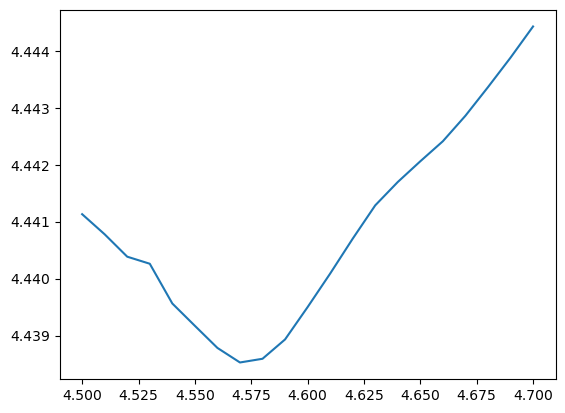

In [18]:
plt.plot(performance_trackerENPH_focused.keys(), performance_trackerENPH_focused.values())